# 03 — Data Cleaning
**Hotel Booking Demand Dataset**

This notebook applies all necessary cleaning transformations to the raw dataset:
- Imputing missing values
- Removing invalid ADR records
- Deduplicating rows

The cleaned dataset is saved to `/data/cleaned/` for downstream analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.float_format", "{:.4f}".format)


## Load Raw Dataset

In [2]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")

print(f"{'─'*45}")
print(f"  Raw dataset shape : {df.shape[0]:>7,} rows × {df.shape[1]} columns")
print(f"{'─'*45}")
ORIGINAL_ROWS = df.shape[0]


─────────────────────────────────────────────
  Raw dataset shape : 119,390 rows × 32 columns
─────────────────────────────────────────────


In [3]:
# Tracking dict — records shape after every step
cleaning_log = {"00 · Raw": df.shape[0]}


---
## Step 1 — Impute Missing Values

### 1a. `children` → fill with `0`


In [4]:
n_children = df["children"].isnull().sum()
df["children"] = df["children"].fillna(0).astype(int)

print(f"  children  — filled {n_children:>6,} NaN values with 0")
print(f"  Shape after step 1a : {df.shape}")
cleaning_log["01a · children filled"] = df.shape[0]


  children  — filled      4 NaN values with 0
  Shape after step 1a : (119390, 32)


### 1b. `agent` → fill with `0`

In [5]:
n_agent = df["agent"].isnull().sum()
df["agent"] = df["agent"].fillna(0).astype(int)

print(f"  agent     — filled {n_agent:>6,} NaN values with 0")
print(f"  Shape after step 1b : {df.shape}")
cleaning_log["01b · agent filled"] = df.shape[0]


  agent     — filled 16,340 NaN values with 0
  Shape after step 1b : (119390, 32)


### 1c. `company` → fill with `0`

In [6]:
n_company = df["company"].isnull().sum()
df["company"] = df["company"].fillna(0).astype(int)

print(f"  company   — filled {n_company:>6,} NaN values with 0")
print(f"  Shape after step 1c : {df.shape}")
cleaning_log["01c · company filled"] = df.shape[0]


  company   — filled 112,593 NaN values with 0
  Shape after step 1c : (119390, 32)


### 1d. `country` → fill with mode

In [7]:
n_country    = df["country"].isnull().sum()
country_mode = df["country"].mode()[0]
df["country"] = df["country"].fillna(country_mode)

print(f"  country   — filled {n_country:>6,} NaN values with mode = '{country_mode}'")
print(f"  Shape after step 1d : {df.shape}")
cleaning_log["01d · country filled"] = df.shape[0]

# Verify — no missing values remain
remaining = df.isnull().sum().sum()
print(f"\n  ✅ Total remaining NaN values in dataset: {remaining}")


  country   — filled    488 NaN values with mode = 'PRT'
  Shape after step 1d : (119390, 32)

  ✅ Total remaining NaN values in dataset: 0


---
## Step 2 — Remove Invalid ADR Records

Rows where `adr` (Average Daily Rate) ≤ 0 are economically impossible and indicate
data entry errors or test records. These are removed before any pricing analysis.


In [8]:
# Inspect invalid ADR records
adr_invalid = df[df["adr"] <= 0]
print(f"  Rows with adr <= 0 : {len(adr_invalid):,}")
print(f"    · adr == 0       : {(df['adr'] == 0).sum():,}")
print(f"    · adr < 0        : {(df['adr'] < 0).sum():,}")
print(f"    · min adr value  : {df['adr'].min():.2f}")
print()

# Preview a few invalid rows
adr_invalid[["hotel", "is_canceled", "adr", "reservation_status",
             "arrival_date_year", "customer_type"]].head(5)


  Rows with adr <= 0 : 1,960
    · adr == 0       : 1,959
    · adr < 0        : 1
    · min adr value  : -6.38



,hotel,is_canceled,adr,reservation_status,arrival_date_year,customer_type
0,Resort Hotel,0,0.0000,Check-Out,2015,Transient
1,Resort Hotel,0,0.0000,Check-Out,2015,Transient
125,Resort Hotel,0,0.0000,Check-Out,2015,Transient
167,Resort Hotel,0,0.0000,Check-Out,2015,Transient
168,Resort Hotel,0,0.0000,Check-Out,2015,Transient


In [9]:
before_adr = df.shape[0]
df = df[df["adr"] > 0].reset_index(drop=True)

rows_removed = before_adr - df.shape[0]
print(f"  Rows removed (adr <= 0) : {rows_removed:,}")
print(f"  Shape after step 2      : {df.shape}")
cleaning_log["02 · invalid ADR removed"] = df.shape[0]


  Rows removed (adr <= 0) : 1,960
  Shape after step 2      : (117430, 32)


---
## Step 3 — Remove Duplicate Rows


In [10]:
before_dedup = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)

dupes_removed = before_dedup - df.shape[0]
print(f"  Duplicate rows removed  : {dupes_removed:,}")
print(f"  Shape after step 3      : {df.shape}")
cleaning_log["03 · duplicates removed"] = df.shape[0]


  Duplicate rows removed  : 31,832
  Shape after step 3      : (85598, 32)


---
## Cleaning Summary


In [11]:
summary_df = pd.DataFrame(
    list(cleaning_log.items()), columns=["Step", "Rows Remaining"]
)
summary_df["Rows Removed (cumulative)"] = ORIGINAL_ROWS - summary_df["Rows Remaining"]
summary_df["% of Original"] = (summary_df["Rows Remaining"] / ORIGINAL_ROWS * 100).round(2)

print(summary_df.to_string(index=False))
print()
print(f"  Original rows        : {ORIGINAL_ROWS:>7,}")
print(f"  Final clean rows     : {df.shape[0]:>7,}")
print(f"  Total rows removed   : {ORIGINAL_ROWS - df.shape[0]:>7,}  "
      f"({(ORIGINAL_ROWS - df.shape[0]) / ORIGINAL_ROWS * 100:.2f}% of dataset)")


                    Step  Rows Remaining  Rows Removed (cumulative)  % of Original
                00 · Raw          119390                          0       100.0000
   01a · children filled          119390                          0       100.0000
      01b · agent filled          119390                          0       100.0000
    01c · company filled          119390                          0       100.0000
    01d · country filled          119390                          0       100.0000
02 · invalid ADR removed          117430                       1960        98.3600
 03 · duplicates removed           85598                      33792        71.7000



  Original rows        : 119,390
  Final clean rows     :  85,598
  Total rows removed   :  33,792  (28.30% of dataset)


### Cleaning Funnel — Row Count at Each Step

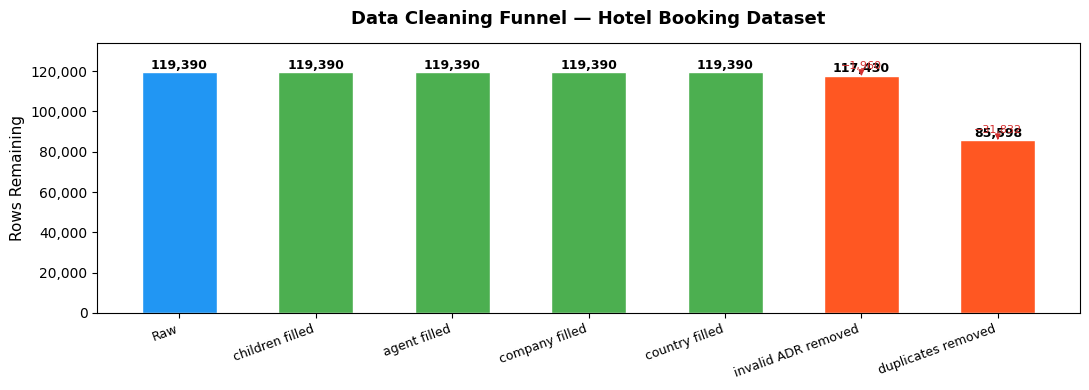

Chart saved to visuals/cleaning_funnel.png


In [12]:
steps  = list(cleaning_log.keys())
counts = list(cleaning_log.values())

# Shorten labels for the chart
labels = [s.split("·")[-1].strip() for s in steps]

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#2196F3" if i == 0 else
          "#4CAF50" if i < len(steps) - 2 else
          "#FF5722" if "ADR" in steps[i] or "dup" in steps[i]
          else "#4CAF50"
          for i in range(len(steps))]

bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.55)

# Annotate bars
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Rows Remaining", fontsize=11)
ax.set_title("Data Cleaning Funnel — Hotel Booking Dataset",
             fontsize=13, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, max(counts) * 1.12)
plt.xticks(rotation=20, ha="right", fontsize=9)

# Highlight drops
for i in range(1, len(counts)):
    drop = counts[i-1] - counts[i]
    if drop > 0:
        ax.annotate(f"−{drop:,}", xy=(i, counts[i] + 200),
                    xytext=(i, counts[i] + 3500),
                    ha="center", fontsize=8, color="#d32f2f",
                    arrowprops=dict(arrowstyle="-|>", color="#d32f2f", lw=1))

plt.tight_layout()
plt.savefig("../visuals/cleaning_funnel.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved to visuals/cleaning_funnel.png")


## Save Cleaned Dataset

In [13]:
output_path = "../data/cleaned/hotel_bookings_cleaned.csv"
df.to_csv(output_path, index=False)

print(f"  ✅ Cleaned dataset saved to: {output_path}")
print(f"  Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()

# Quick sanity check
print("Remaining nulls per column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  None — dataset is fully clean ✅")

print()
print("ADR statistics (post-cleaning):")
print(df["adr"].describe().round(2))


  ✅ Cleaned dataset saved to: ../data/cleaned/hotel_bookings_cleaned.csv
  Final shape : 85,598 rows × 32 columns

Remaining nulls per column:
  None — dataset is fully clean ✅

ADR statistics (post-cleaning):
count   85598.0000
mean      108.5600
std        53.3700
min         0.2600
25%        74.5000
50%        99.0000
75%       135.0000
max      5400.0000
Name: adr, dtype: float64


---
## Cleaning Decisions — Summary & Rationale

### Rows Overview

| Metric | Value |
|--------|-------|
| Original rows | 119,390 |
| Rows after imputation | 119,390 (no rows removed) |
| Rows removed — invalid ADR | 1,960 |
| Rows removed — duplicates | 31,832 |
| **Final clean rows** | **85,598** |
| Total removed | 33,792 (28.30% of dataset) |

---

### Decision 1 — `children`: Fill NaN → `0`  *(4 rows affected)*

**Why:** Only 4 records had a missing `children` value. Given that the overwhelming majority of bookings have `children = 0`, and the absence of a value is most logically interpreted as "no children," filling with `0` is both safe and semantically correct. The impact on any downstream analysis is negligible.

---

### Decision 2 — `agent`: Fill NaN → `0`  *(16,340 rows affected)*

**Why:** A missing `agent` ID does not mean the data is corrupted — it means the booking was made **directly** (without a travel agent). Using `0` as a sentinel value clearly distinguishes "no agent" from legitimate agency IDs and allows the column to remain numeric for modelling. A binary flag `has_agent` can be derived from this if needed.

---

### Decision 3 — `company`: Fill NaN → `0`  *(112,593 rows affected)*

**Why:** Same logic as `agent`. 94.3% of bookings have no corporate account — they are individual or leisure bookings. `NULL` → `0` cleanly encodes "no corporate account." This preserves the column for model use without fabricating values. The high missingness rate (>94%) also makes it unsuitable as a direct predictive feature; it should be transformed into a binary `is_corporate_booking` flag.

---

### Decision 4 — `country`: Fill NaN → Mode (`'PRT'`)  *(488 rows affected)*

**Why:** Country is a low-missingness column (0.41%). The data source (Antonio et al.) originates from Portuguese hotels, and `PRT` is by far the most frequent country in the dataset. Mode imputation is appropriate here — it introduces minimal bias and is preferable to dropping nearly 500 otherwise complete records. An `"Unknown"` label could alternatively be used for models that handle categorical unknowns.

---

### Decision 5 — Drop rows where `adr <= 0`  *(1,960 rows removed)*

**Why:** `adr` (Average Daily Rate) is the core revenue metric. A rate of `0` or negative is economically nonsensical for a hotel booking and indicates:
- Test or dummy records
- Data entry errors
- Complimentary stays misclassified as bookings

These records would corrupt any pricing analysis, regression targets, or revenue modelling. Removing them is the safest approach since we cannot reliably infer the correct rate.

---

### Decision 6 — Drop exact duplicate rows  *(31,832 rows removed)*

**Why:** The dataset contains a large number of exact duplicate rows (31,832 — approximately 26.7% of records after ADR cleaning). These are likely caused by repeated data exports or system logging artifacts. Keeping them would:
- Artificially inflate cancellation rates
- Skew frequency distributions
- Introduce data leakage in train/test splits

`.drop_duplicates()` removes rows that are **completely identical** across all 32 columns, which is a conservative and safe deduplication strategy.
